# Proyek Analisis Data: Bike Sharing Dataset
- **Nama:** Farrell Valentino Wempie
- **Email:** farrell.valentinos@gmail.com
- **ID Dicoding:** megamind

## Menentukan Pertanyaan Bisnis

**SMART Question** adalah sebuah framework untuk merumuskan pertanyaan secara terstruktur agar memeperoleh informasi yang mendalam.

* **Spesific (Spesifik)**
  * Pertanyaan harus jelas, fokus pada sebuah topik tertentu, dan tidak bermakna ganda. Hindari pertanyaan yang terlalu luas.
    * Salah: Bagaimana cara meningkatkan penjualan?
    * Benar: Faktor apa saja yang memengaruhi penurunan penjualan produk kategori elektronik di wilayah Jakarta selama kuartal terakhir?
* **Measurable (Terukur)**
  * Pertanyaan harus bisa dijawab dengan angka atau matrix yang konkret, harus tahu apa yang akan dihitung.
    * Salah: Apakah pelanggan senang dengan layanan kita?
    * Benar: Berapa skor rata-rata Customer Satisfaction untuk layanan purna jual bulan ini dibandingkan bulan lalu?
* **Action-Oriented (Berorientasi Aksi)**
  * Hasil dari pertanyaan harus bisa memberikan arahan untuk melakukan tindakan nyata. Jika pertanyaan terjawab, stakeholder harus tahu apa langkah selanjutnya.
    * Salah: Mengapa orang suka berbelanja?
    * Benar: Fitur apa pada aplikasi yang paling sering digunakan sebelum pengguna memutuskan untuk melakukan checkout?
* **Relevant (Relevan)**
  * Hasil dari pertanyaan harus sejalan dengan tujuan utama bisnis atau masalah yang sedang dihadapi.
    * Salah: Menanyakan tentang stok gudang saat masalah utamanya adalah efektivitas kampanye media sosial.
    * Benar: Apakah kampanye iklan di Instagram memberikan Return on Ad Spend (ROAS) yang lebih tinggi dibandingkan iklan di TikTok?
* **Time-bound (Terikat Waktu)**
  * Pertanyaan harus ada batasan waktu yang jelas agar analisis memiliki konteks yang tepat.
    * Salah: Berapa banyak pengguna baru kita?
    * Benar: Berapa tingkat pertumbuhan pengguna baru secara bulanan (Month-over-Month) sepanjang tahun 2025?

**Contoh pertanyaan bisnis yang memenuhi seluruh elemen SMART**

***"Faktor apa saja yang memengaruhi penurunan conversion rate pada pengguna aplikasi Android di wilayah Jabodetabek sebesar 5% selama periode Flash Sale Maret 2026?"***

Keterangan:

- **Specific**: Fokus pada "penurunan conversion rate" untuk "aplikasi Android" di "Jabodetabek". Bukan sekadar penjualan turun.
- **Measurable**: Ada angka konkret yang ingin dianalisis, yaitu penurunan sebesar "5%".
- **Action-Oriented**: Dengan mengetahui faktor penyebabnya misalnya bug pada versi Android tertentu atau kendala logistik di Jabodetabek, tim bisa langsung melakukan perbaikan teknis atau operasional.
- **Relevant**: Penurunan konversi saat Flash Sale adalah masalah kritis bagi bisnis retail/e-commerce.
- **Time-bound**: Dibatasi pada periode spesifik "Flash Sale Maret 2026".

- **Pertanyaan 1:** Bagaimana pola distribusi rata-rata penyewaan sepeda (total, casual, dan registered) berdasarkan jam operasional pada hari kerja (workingday) selama tahun 2011-2012, dan pada jam berapa puncak permintaan terjadi?

- **Pertanyaan 2:** Kondisi cuaca (weathersit) seperti apa yang menghasilkan total penyewaan terendah dan tertinggi, dan bagaimana fluktuasi permintaan ini jika dipecah ke dalam berbagai kategori waktu (Pagi/Siang/Sore/Malam)?


## Import Semua Packages/Library yang Digunakan

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Data Wrangling

### Gathering Data

#### Load df day.csv dan hour.csv


In [ ]:
day_df = pd.read_csv("day.csv")
hour_df = pd.read_csv("hour.csv")

In [ ]:
# menampilkan head dari dataset
display(day_df.head(3))
display(hour_df.head(3))

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,1/1/2011,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,1/2/2011,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,1/3/2011,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349


,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,1/1/2011,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,1/1/2011,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,1/1/2011,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32


**Insight:** (Opsional)
- Dataset day.csv merepresentasikan data agregasi harian selama 2 tahun yaitu dari tahun 2011-2012.

- Dataset hour.csv  merepresentasikan data log per jam. Kedua dataset memiliki struktur informasi yang hampir sama, namun hour.csv jauh lebih granular karena memiliki tambahan fitur hr / jam operasional

### Assessing Data

#### Identifying data problem
Melakukan pengecekan tipe data, missing values, dan data duplikat pada kedua dataset

In [ ]:
# Melihat deskripsi dataset hour.csv
print(hour_df.info())



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), object(1)
memory usage: 2.3+ MB
None


In [ ]:
# mengecek jumlah duplikat dataset hour.csv
print(hour_df.duplicated().sum())

0


In [ ]:
# Melihat deskripsi dataset day.csv
print(day_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB
None


In [ ]:
# mengecek jumlah duplikat dataset day.csv
print( day_df.duplicated().sum())

0


**Steps to Take:**
- **Inconsistent/Unreadable Value:** Kolom seperti season, yr, dan weathersit menggunakan angka representatif. Perlu di mapping ke bentuk string (kategori) agar mudah dibaca di visualisasi.
- **Tipe Data:** Kolom dteday masih bertipe object, harus diubah menjadi datetime.
- **Penamaan:** Mengubah singkatan kolom yang kurang jelas (seperti cnt menjadi total_count, yr menjadi year).

**Insight:** (Opsional)
- Secara keseluruhan kualitas data sangat baik, dibuktikan dengan tidak adanya data duplikat (0 duplikat) maupun missing values pada kedua dataset.

- Namun, secara format dan kemudahan interpretasi (readability) masih ada kendala: tipe data tanggal (dteday) masih terbaca sebagai objek/string, dan fitur kategorikal (seperti musim dan kondisi cuaca) masih di-encode menggunakan angka numerik (1, 2, 3, 4) sehingga berpotensi membingungkan stakeholder saat divisualisasikan.

### Cleaning Data

#### Fixing data problem
Menerapkan langkah-langkah pembersihan data sesuai dengan temuan di tahap Assessing data

In [ ]:
# 1. Mengubah tipe data menjadi datetime
day_df['dteday'] = pd.to_datetime(day_df['dteday'])
hour_df['dteday'] = pd.to_datetime(hour_df['dteday'])

In [ ]:
# 2. Mapping nilai kategori
season_mapping = {1: 'Spring', 2: 'Summer', 3: 'Fall', 4: 'Winter'}
weather_mapping = {1: 'Clear', 2: 'Cloudy/Mist', 3: 'Light Rain/Snow', 4: 'Heavy Rain/Snow'}
year_mapping = {0: 2011, 1: 2012}

if hour_df['season'].dtype == 'int64':
    hour_df['season'] = hour_df['season'].map(season_mapping)
    hour_df['weathersit'] = hour_df['weathersit'].map(weather_mapping)
    hour_df['yr'] = hour_df['yr'].map(year_mapping)

if day_df['season'].dtype == 'int64':
    day_df['season'] = day_df['season'].map(season_mapping)
    day_df['weathersit'] = day_df['weathersit'].map(weather_mapping)
    day_df['yr'] = day_df['yr'].map(year_mapping)

In [ ]:
# 3. Rename kolom agar lebih representatif
rename_dict = {'yr': 'year', 'mnth': 'month', 'hr': 'hour', 'cnt': 'total_count', 'hum': 'humidity'}
day_df.rename(columns=rename_dict, inplace=True, errors='ignore')
hour_df.rename(columns=rename_dict, inplace=True, errors='ignore')

**Insight:** (Opsional)
- Kolom dteday kini telah sukses dikonversi menjadi format datetime yang tepat untuk analisis time series.

- Nilai numerik pada fitur kategorikal (musim, cuaca, tahun) telah di-mapping menjadi label string yang deskriptif, dan nama kolom telah distandardisasi agar lebih intuitif. Dataset kini telah bersih dan siap digunakan untuk fase EDA.

## Exploratory Data Analysis (EDA)

### Explore Penyewaan Berdasarkan Jam dan Hari Kerja

In [ ]:
# Eksplorasi penyewaan per jam khusus di hari kerja
workingday_hourly = hour_df[hour_df['workingday'] == 1].groupby('hour').agg({
    'casual': 'mean',
    'registered': 'mean',
    'total_count': 'mean'
}).reset_index()

display(workingday_hourly.sort_values(by='total_count', ascending=False).head())

,hour,casual,registered,total_count
17,17,56.895792,468.394790,525.290581
18,18,50.451807,441.775100,492.226908
8,8,22.264113,454.741935,477.006048
19,19,41.022088,307.379518,348.401606
16,16,48.344689,244.777555,293.122244


**Insight:** (Opsional)
- Berdasarkan hasil agregasi awal, terlihat jelas bahwa pada hari kerja (workingday), rata-rata penyewaan sepeda tertinggi terjadi pada jam-jam komuter sibuk, yakni jam 17:00 (Sore) dan jam 08:00 (Pagi).

- Menariknya, tingginya angka penyewaan pada peak hours tersebut hampir sepenuhnya didominasi oleh pengguna dari kelompok registered (member tetap), sedangkan rata-rata pengguna casual jauh lebih rendah.

## Visualization & Explanatory Analysis

### Pertanyaan 1:

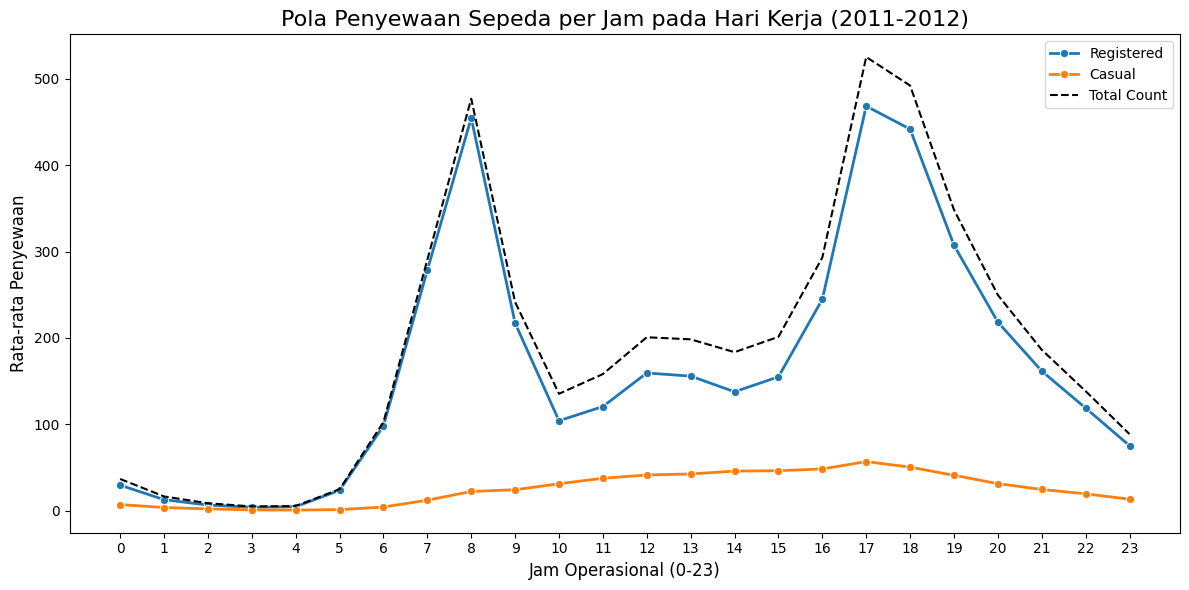

In [ ]:
plt.figure(figsize=(12, 6))
sns.lineplot(x='hour', y='registered', data=workingday_hourly, label='Registered', marker='o', linewidth=2)
sns.lineplot(x='hour', y='casual', data=workingday_hourly, label='Casual', marker='o', linewidth=2)
sns.lineplot(x='hour', y='total_count', data=workingday_hourly, label='Total Count', linestyle='--', color='black')

plt.title('Pola Penyewaan Sepeda per Jam pada Hari Kerja (2011-2012)', fontsize=16)
plt.xlabel('Jam Operasional (0-23)', fontsize=12)
plt.ylabel('Rata-rata Penyewaan', fontsize=12)
plt.xticks(range(0, 24))
plt.legend()
plt.tight_layout()
plt.show()

### Pertanyaan 2:

/tmp/ipykernel_1337/296085419.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="weathersit", y="total_count", data=day_df, estimator=sum, errorbar=None, palette="viridis")


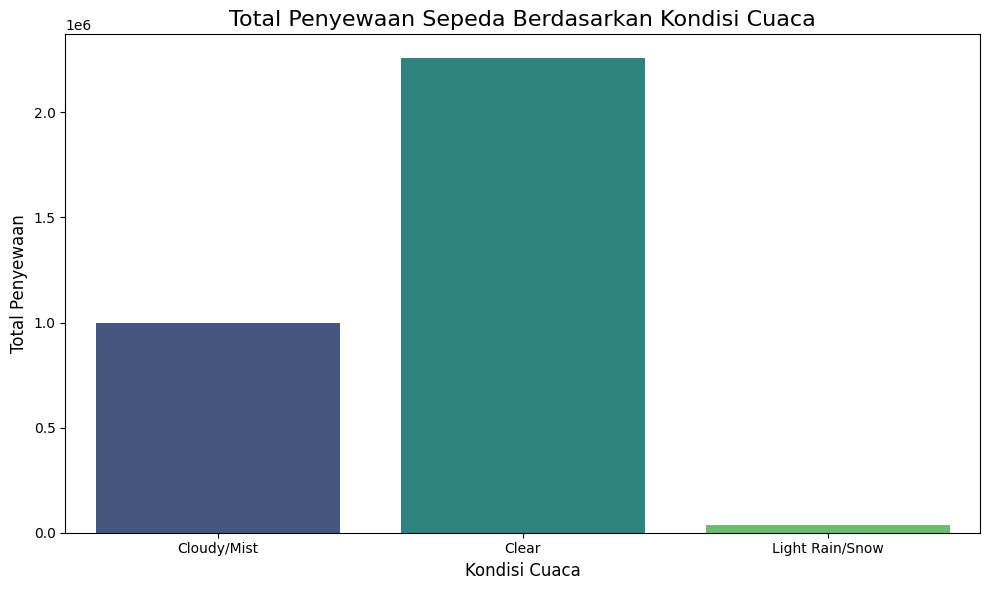

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(x="weathersit", y="total_count", data=day_df, estimator=sum, errorbar=None, palette="viridis")

plt.title('Total Penyewaan Sepeda Berdasarkan Kondisi Cuaca', fontsize=16)
plt.xlabel('Kondisi Cuaca', fontsize=12)
plt.ylabel('Total Penyewaan', fontsize=12)
plt.tight_layout()
plt.show()

**Insight:** (Opsional)
- Visualisasi pertama mengonfirmasi pola bimodal (dua puncak) pada pengguna registered di hari kerja, yang mengindikasikan bahwa sepeda sangat diandalkan sebagai moda transportasi utama untuk berangkat dan pulang kerja.

- Visualisasi kedua menunjukkan bahwa secara absolut, cuaca cerah (Clear/Partly Cloudy) mencetak volume penyewaan tertinggi. Kenaikan intensitas presipitasi (hujan/salju) berkorelasi negatif secara drastis terhadap minat penyewaan sepeda.

## Analisis Lanjutan (Opsional)
Menerapkan teknik Binning untuk mengelompokkan jam operasional ke dalam "Kategori Waktu" guna melihat performa lebih spesifik saat cuaca memburuk.

In [ ]:
# 1. Binning function
def categorize_time(hour):
    if 5 <= hour < 12:
        return 'Pagi'
    elif 12 <= hour < 17:
        return 'Siang'
    elif 17 <= hour < 21:
        return 'Sore'
    else:
        return 'Malam'

In [ ]:
# 2. Apply binning
hour_df['time_category'] = hour_df['hour'].apply(categorize_time)

In [ ]:
# 3. Aggregation (Cuaca vs Kategori Waktu)
weather_time_clustering = hour_df.groupby(['weathersit', 'time_category'])['total_count'].mean().unstack()

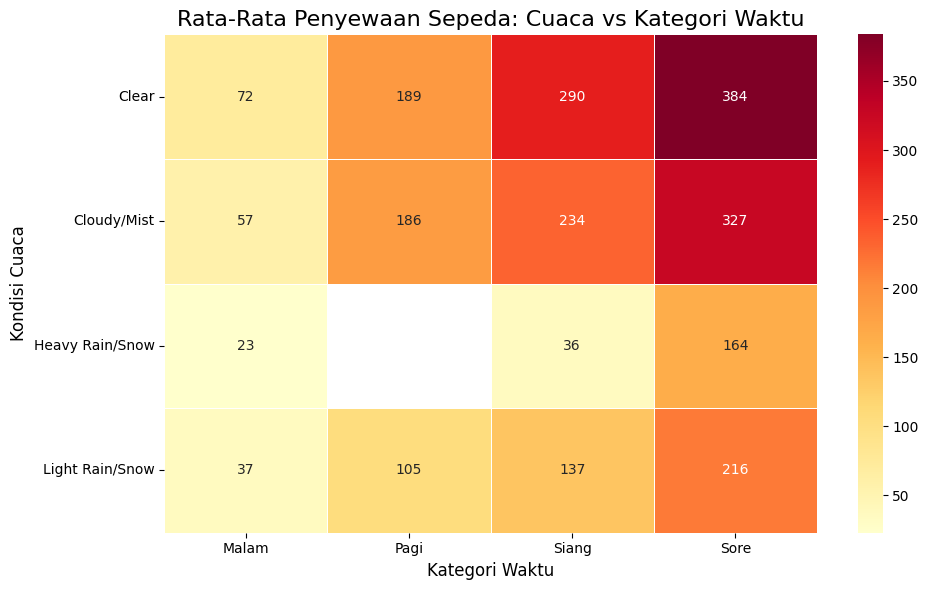

In [ ]:
# 4. Heatmap Visualization
plt.figure(figsize=(10, 6))
sns.heatmap(weather_time_clustering, annot=True, fmt=".0f", cmap="YlOrRd", linewidths=.5)
plt.title('Rata-Rata Penyewaan Sepeda: Cuaca vs Kategori Waktu', fontsize=16)
plt.xlabel('Kategori Waktu', fontsize=12)
plt.ylabel('Kondisi Cuaca', fontsize=12)
plt.tight_layout()
plt.show()

In [ ]:
# Save data untuk Dashboard Streamlit
hour_df.to_csv("main_data.csv", index=False)

**Insight:** (Opsional)
- Melalui matriks Heatmap berbasis Binning waktu, kita dapat melihat dampak cuaca secara lebih presisi. Saat cuaca buruk ("Light Rain/Snow" atau "Heavy Rain/Snow"), minat sewa di waktu "Pagi" dan "Malam" menjadi titik paling rentan (sangat rendah).

- Sebaliknya, cuaca "Clear" di kategori waktu "Sore" menjadi sweet spot dengan rata-rata penyewaan tertinggi mencapai lebih dari 380 unit per jam. Analisis metrik silang ini sangat vital untuk merancang strategi dynamic pricing atau alokasi logistik di lapangan.

## Conclusion & Recommendation

- **Conclusion pertanyaan 1:** Pola penyewaan sepeda pada hari kerja sangat dipengaruhi oleh rutinitas perkantoran/sekolah. Puncak permintaan terjadi dua kali, yaitu pada pukul 08:00 dan pukul 17:00. Pengguna tipe "Registered" sangat mendominasi pada jam-jam sibuk ini, sementara jumlah penyewa "Casual" cenderung rendah dan stagnan sepanjang hari
- **Conclusion pertanyaan 2:** Cuaca "Clear" menghasilkan total penyewaan tertinggi secara absolut. Namun, berdasarkan hasil analisis lanjutan (binning), saat kondisi cuaca memburuk menjadi "Light Rain/Snow" atau "Heavy Rain/Snow", permintaan langsung anjlok sangat drastis ke angka terendah, terutama pada kategori waktu "Malam" dan "Pagi"

**Rekomendasi Action Item:**
- **Bagian Operasional:** Tim logistik wajib memastikan ketersediaan unit sepeda dimaksimalkan pada pukul 07:30 dan 16:30 di stasiun-stasiun strategis (dekat stasiun kereta/area perkantoran) pada hari kerja untuk menyerap tingginya demand dari pengguna "Registered".
- **Bagian Marketing:** Untuk meminimalisir meruginya revenue akibat unit yang menganggur di saat hujan/salju, tim marketing dapat meluncurkan kampanye diskon cuaca buruk / Bad Weather Promo  yang ditargetkan secara otomatis via notifikasi aplikasi pada pagi atau malam hari saat terdeteksi presipitasi tinggi.